The objective of this program is to analyze a high-dimensional socio-economic and health dataset by applying Principal Component Analysis (PCA) to reduce dimensionality and extract the most significant underlying factors.

These principal components are then used as input features in a Logistic Regression model to predict the likelihood of child malnutrition.

## Objectives

- Reduce redundancy and multicollinearity among variables  
- Improve computational efficiency  
- Identify latent structures influencing malnutrition  
- Build a predictive model for classification of malnutrition risk  

## Dataset Description

This dataset is a survey-style dataset designed to resemble large-scale Indian household surveys such as the National Family Health Survey. It contains **100,000 observations**, where each row represents a household or child with multiple socio-economic, health, and environmental attributes.

The variables are structured around key development dimensions such as:

- Income  
- Food security  
- Health status  
- Education  
- Gender factors  
- Sanitation  
- Infrastructure  
- Climate risks  

These features collectively capture the multidimensional causes of child malnutrition.

## Data Characteristics

- Includes both **continuous variables** (e.g., income, dietary diversity)  
- Includes **categorical/binary indicators** (e.g., immunization status, access to clean water)  

A target variable, **`Malnutrition_Risk`**, is included as a binary outcome indicating whether a child is at high or low risk of malnutrition.

Although the data is synthetically generated, it follows realistic statistical distributions, making it suitable for applying techniques like PCA and Logistic Regression for analysis and modeling.

In [1]:
import pandas as pd


### Load dataset


In [2]:
url = "https://raw.githubusercontent.com/iPriyadarshi/MachineLearning-BCS4706/main/dataset/sdg_malnutrition_dataset.csv"
df = pd.read_csv(url)


### Basic checks

In [3]:
df.head()


,Household_Income,Poverty_Status,Food_Expenditure_Ratio,Social_Protection_Access,Food_Availability,Dietary_Diversity_Score,Meal_Frequency,Child_Feeding_Practices,Child_Health_Status,Immunization_Status,...,Access_To_Services_Equity,Housing_Condition,Slum_Residence,Population_Density,Food_Wastage_Level,Food_Storage_Practices,Climate_Shock_Exposure,Crop_Failure_Incidence,Weather_Variability,Malnutrition_Risk
0,28236.114017,0,0.663549,1,0.683364,8,1,0.258585,0.791974,0,...,0.474607,0.940448,0,13379,0.860530,0.335483,0,0,0.005176,0
1,20555.171637,0,0.456270,1,0.831084,5,2,0.944793,0.665151,1,...,0.276406,0.732535,0,14585,0.165408,0.230523,0,0,0.408611,0
2,30450.091226,0,0.493708,1,0.825048,7,2,0.655804,0.364330,1,...,0.539590,0.421672,1,4186,0.038422,0.199440,1,1,0.122318,0
3,47170.073204,1,0.592818,1,0.514674,5,4,0.768238,0.327269,1,...,0.373299,0.482478,0,14713,0.504149,0.906650,1,0,0.808787,0
4,19592.915242,0,0.469154,0,0.772103,9,4,0.196116,0.162214,1,...,0.093860,0.489095,1,14006,0.435767,0.782797,0,0,0.251836,0


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 41 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Household_Income             100000 non-null  float64
 1   Poverty_Status               100000 non-null  int64  
 2   Food_Expenditure_Ratio       100000 non-null  float64
 3   Social_Protection_Access     100000 non-null  int64  
 4   Food_Availability            100000 non-null  float64
 5   Dietary_Diversity_Score      100000 non-null  int64  
 6   Meal_Frequency               100000 non-null  int64  
 7   Child_Feeding_Practices      100000 non-null  float64
 8   Child_Health_Status          100000 non-null  float64
 9   Immunization_Status          100000 non-null  int64  
 10  Disease_Incidence            100000 non-null  int64  
 11  Maternal_Health_Status       100000 non-null  float64
 12  Mother_Education_Level       100000 non-null  int64  
 13  Nutrition_A

In [5]:
df.nunique()


Household_Income               100000
Poverty_Status                      2
Food_Expenditure_Ratio         100000
Social_Protection_Access            2
Food_Availability              100000
Dietary_Diversity_Score             9
Meal_Frequency                      4
Child_Feeding_Practices        100000
Child_Health_Status            100000
Immunization_Status                 2
Disease_Incidence                  11
Maternal_Health_Status         100000
Mother_Education_Level             16
Nutrition_Awareness            100000
School_Attendance              100000
Women_Decision_Making_Index    100000
Early_Marriage_Indicator            2
Maternal_Autonomy              100000
Access_To_Clean_Water               2
Sanitation_Facility_Type            3
Hygiene_Practices              100000
Cooking_Fuel_Type                   3
Electricity_Access                  2
Employment_Status                   2
Job_Stability                  100000
Household_Working_Members           4
Healthcare_F

### Separate categorical and numerical columns

In [6]:
# Automatically detect categorical columns (<= 20 unique values)

categorical_cols = []

for col in df.columns:
    if df[col].nunique() <= 20:
        categorical_cols.append(col)

print("Categorical Columns:")
print(categorical_cols)


Categorical Columns:
['Poverty_Status', 'Social_Protection_Access', 'Dietary_Diversity_Score', 'Meal_Frequency', 'Immunization_Status', 'Disease_Incidence', 'Mother_Education_Level', 'Early_Marriage_Indicator', 'Access_To_Clean_Water', 'Sanitation_Facility_Type', 'Cooking_Fuel_Type', 'Electricity_Access', 'Employment_Status', 'Household_Working_Members', 'Slum_Residence', 'Climate_Shock_Exposure', 'Crop_Failure_Incidence', 'Malnutrition_Risk']


In [7]:
# Separate categorical & numerical

df_categorical = df[categorical_cols].copy()
df_numerical = df.drop(columns=categorical_cols).copy()


### Scaling

In [8]:
# Scale numerical features
from sklearn.preprocessing import StandardScaler

scaler_num = StandardScaler()
df_numerical_scaled = scaler_num.fit_transform(df_numerical)
print(df_numerical_scaled.shape)


(100000, 23)


In [9]:
# Scale categorical features (already encoded numerically)
from sklearn.preprocessing import MinMaxScaler

scaler_cat = MinMaxScaler()
df_categorical_scaled = scaler_cat.fit_transform(df_categorical)
print(df_categorical_scaled.shape)


(100000, 18)


In [10]:
# Convert back to DataFrame
df_num_scaled = pd.DataFrame(df_numerical_scaled, columns=df_numerical.columns)
df_cat_scaled = pd.DataFrame(df_categorical_scaled, columns=df_categorical.columns)

# Merge datasets
df_scaled = pd.concat([df_num_scaled, df_cat_scaled], axis=1)


In [11]:
df_scaled.head()


,Household_Income,Food_Expenditure_Ratio,Food_Availability,Child_Feeding_Practices,Child_Health_Status,Maternal_Health_Status,Nutrition_Awareness,School_Attendance,Women_Decision_Making_Index,Maternal_Autonomy,...,Access_To_Clean_Water,Sanitation_Facility_Type,Cooking_Fuel_Type,Electricity_Access,Employment_Status,Household_Working_Members,Slum_Residence,Climate_Shock_Exposure,Crop_Failure_Incidence,Malnutrition_Risk
0,0.245130,1.417488,-0.462994,-0.839371,1.011879,-1.495799,1.344270,1.696526,0.792776,-0.705096,...,1.0,0.0,1.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.0
1,-0.332286,-0.378586,0.563031,1.537982,0.572949,-1.308903,0.665996,0.090767,0.715607,1.186270,...,0.0,1.0,1.0,1.0,0.0,0.666667,0.0,0.0,0.0,0.0
2,0.411566,-0.054191,0.521107,0.536786,-0.468177,-1.447550,-0.688739,0.366906,-1.609470,1.193888,...,1.0,0.0,0.5,1.0,0.0,0.000000,1.0,1.0,1.0,0.0
3,1.668492,0.804600,-1.634673,0.926310,-0.596445,-1.521181,-0.088532,0.736090,-1.032584,0.907314,...,1.0,0.5,1.0,1.0,1.0,0.000000,0.0,1.0,0.0,0.0
4,-0.404624,-0.266947,0.153365,-1.055793,-1.167692,0.784254,1.627086,-0.561616,0.613017,-0.039355,...,0.0,0.0,1.0,1.0,1.0,0.666667,1.0,0.0,0.0,0.0


In [12]:
df_scaled.shape


(100000, 41)

### Separate features and target


In [13]:
X = df_scaled.drop(columns=["Malnutrition_Risk"])
y = df_scaled["Malnutrition_Risk"]


### Train-test split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


### PCA

In [15]:
from sklearn.decomposition import PCA
import numpy as np

# pca = PCA(n_components=0.95)    # Retain 95% of variance (Variance threshold)

pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("\nNumber of components selected:", pca.n_components_)
print("Explained Variance Ratio: \n",pca.explained_variance_ratio_)
print("Total Variance Explained:",np.sum(pca.explained_variance_ratio_))



Number of components selected: 10
Explained Variance Ratio: 
 [0.04008032 0.03990935 0.03979927 0.03971124 0.03958801 0.0394655
 0.03940803 0.03930966 0.03920362 0.03916536]
Total Variance Explained: 0.3956403623227015


### Scree plot

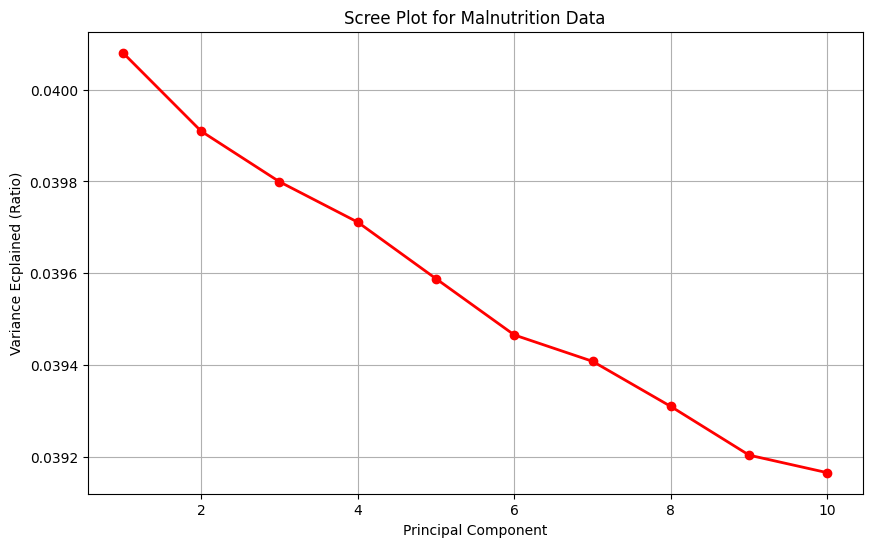

In [16]:
import matplotlib.pyplot as plt

exp_var_ratios = pca.explained_variance_ratio_

plt.figure(figsize=(10,6))

plt.plot(range(1,len(exp_var_ratios)+1),exp_var_ratios,'ro-',linewidth=2)

plt.title("Scree Plot for Malnutrition Data")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ecplained (Ratio)")
plt.grid(True)
plt.show()


### Logistic Regression


In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000,solver='saga')
model.fit(X_train_pca,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Predictions

In [18]:
y_pred = model.predict(X_test_pca)
y_pred_train = model.predict(X_train_pca)


### Evaluation

In [19]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))

print("Classification Report:\n", classification_report(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Test Accuracy: 0.99895
Train Accuracy: 0.999075
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     19963
         1.0       0.86      0.51      0.64        37

    accuracy                           1.00     20000
   macro avg       0.93      0.76      0.82     20000
weighted avg       1.00      1.00      1.00     20000

Confusion Matrix:
 [[19960     3]
 [   18    19]]
